Temp data from : https://power.larc.nasa.gov/data-access-viewer/  
power data from portlandgeneral

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import pymc as pm
import arviz as az

import warnings

warnings.filterwarnings("ignore")


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
df = pd.read_csv('./pgn_electric_usage_interval_data_4960010965_1_2024-01-12_to_2024-11-29.csv')
temp = pd.read_csv('./POWER_Point_Daily_20240112_20241201_045d57N_0122d61W_LST.csv')

In [3]:
grouped = df.groupby('DATE')['USAGE (kWh)'].sum().reset_index()
grouped.head()

,DATE,USAGE (kWh)
0,2024-01-12,53.79
1,2024-01-13,34.44
2,2024-01-14,59.67
3,2024-01-15,130.14
4,2024-01-16,142.21


In [4]:
temp['DATE'] = temp.apply(lambda x: pd.to_datetime(f'{int(x.YEAR)}-{int(x.MO)}-{int(x.DY)}'), axis=1)

In [5]:
temp['temp_f'] = (temp['T2M'] * 9/5) + 32

In [6]:
grouped['DATE'] = pd.to_datetime(grouped['DATE'])

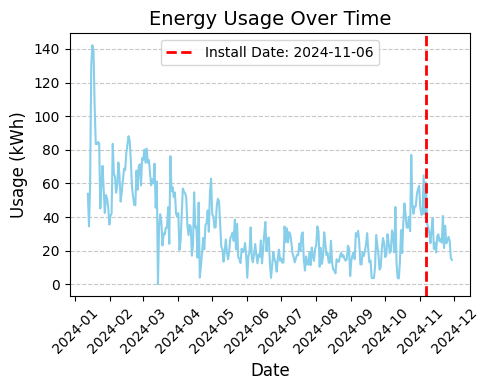

In [7]:
# Target date for the vertical line
install_date = pd.to_datetime("2024-11-06")

# Plot the bar chart
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(grouped["DATE"], grouped["USAGE (kWh)"], color='skyblue')

# Draw the vertical line
ax.axvline(install_date, color='red', linestyle='--', linewidth=2, label=f"Install Date: {install_date.date()}")

# Formatting the chart
ax.set_title("Energy Usage Over Time", fontsize=14)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Usage (kWh)", fontsize=12)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Rotate date labels for better readability
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

In [8]:
grouped['after_install'] = grouped['DATE'] >= install_date

<Axes: xlabel='USAGE (kWh)', ylabel='Density'>

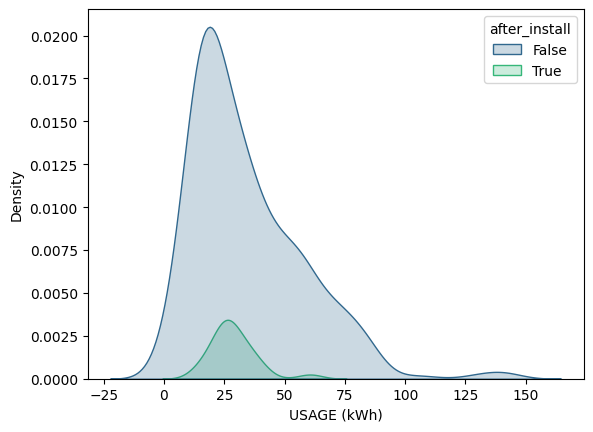

In [9]:
sns.kdeplot(grouped, x='USAGE (kWh)', hue='after_install', palette='viridis', fill=True)

In [10]:
combined_df = grouped.merge(temp, on='DATE')

combined_df = combined_df.loc[combined_df.temp_f > 0]

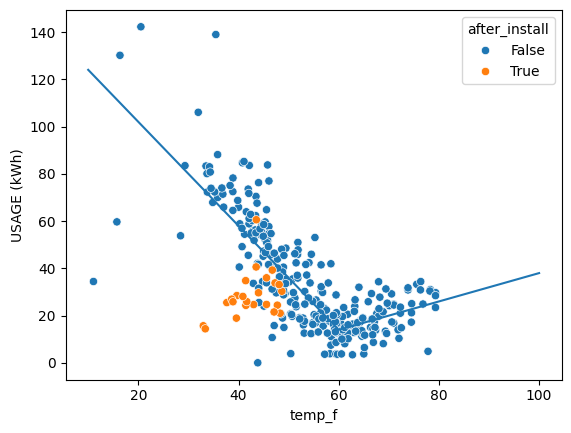

In [46]:
sns.scatterplot(combined_df, x='temp_f', y='USAGE (kWh)', hue='after_install')
x_temp = np.linspace(10, 100, 100)
temp_set = 60
k_heat = 2.2
k_cool = 0.6
min = 14
usage = [k_heat * (temp_set - temp) + min if temp < temp_set else k_cool * (temp - temp_set)  + min for temp in x_temp]
plt.plot(x_temp, usage)

In [12]:
combined_df.head()

,DATE,USAGE (kWh),after_install,YEAR,MO,DY,T2M,temp_f
0,2024-01-12,53.79,False,2024,1,12,-1.98,28.436
1,2024-01-13,34.44,False,2024,1,13,-11.64,11.048
2,2024-01-14,59.67,False,2024,1,14,-9.04,15.728
3,2024-01-15,130.14,False,2024,1,15,-8.70,16.340
4,2024-01-16,142.21,False,2024,1,16,-6.38,20.516


We build the model as follows describing usage as a function of temperature. The split linear function describes a setpoint temperature at minimum power usage, which we assume to be fixed in this model, eyeballing it around 10 from the scatterplot above. temperature above the setpoint, we use power at the rate given by k_cool (kWh / deg_f) and at temperatures below setpoint we use power at the rate k_heat (kWh / deg_f). Usage is positive in all cases. A quick fit of the data above gives us the range of values that may be possible for k_. At any temperature, we assume usage is normally distributed, with the expected value, mu, given by usage as a function of temperature. sigma of the usage distribution, we're setting an ignorant but conservative prior of exponential(lam=1). This may prove to be completely meaningless but the neat part about MCMC, is we'll still probably get a decent fit.

Usage data will be presented as a 2xN data points matrix, with index 0 for before the install and index 1 for after. Temperature will be a 1xN matrix from the observed temperatures. missing values are np.nan and we expect some imputation of the data. We'll see how that goes. At the time of initially writing this we have barely a weeks worth of data after the pump install. This model will develop over time.

In [13]:
combined_df.loc[combined_df.duplicated(subset='temp_f', keep=False)].shape

(60, 8)

In [14]:
# we'll take the mean of temperature for now. There's probably enough data
model_data = combined_df.groupby(['temp_f', 'after_install'])['USAGE (kWh)'].mean().reset_index()

In [15]:
model_data = model_data.pivot(index='temp_f', columns='after_install', values='USAGE (kWh)')

model_data.columns = ['before', 'after']
model_data.head()

,before,after
temp_f,,
11.048,34.44,NaN
15.728,59.67,NaN
16.340,130.14,NaN
20.516,142.21,NaN
28.436,53.79,NaN


In [16]:
coords = {'install': ['before', 'after']}

temp_obs = model_data.index.to_numpy()
usage_obs = model_data.loc[:, ['before', 'after']].to_numpy()

In [17]:
with pm.Model(coords=coords) as norm_model:

    sigma_usage = pm.Exponential('sigma_usage', lam=1, shape=2)

    mu_usage = pm.Normal('mu_usage', mu=25, sigma=10, shape=2)

    usage = pm.Normal('usage', mu=mu_usage, sigma=sigma_usage, observed=usage_obs)

    idata = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_usage, mu_usage, usage_unobserved]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 33 seconds.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [18]:
idata.extend(pm.sample_posterior_predictive(trace=idata, model=norm_model))

Sampling: [usage_observed]


Output()

In [19]:
idata

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_usage[0],34.916,1.430,32.163,37.579,0.017,0.012,7087.0,2940.0,1.00
mu_usage[1],28.452,1.753,25.110,31.657,0.076,0.054,531.0,753.0,1.00
sigma_usage[0],22.944,0.933,21.242,24.728,0.011,0.008,7284.0,3038.0,1.00
sigma_usage[1],8.478,1.071,6.619,10.536,0.060,0.043,305.0,502.0,1.01


<Axes: xlabel='usage_observed'>

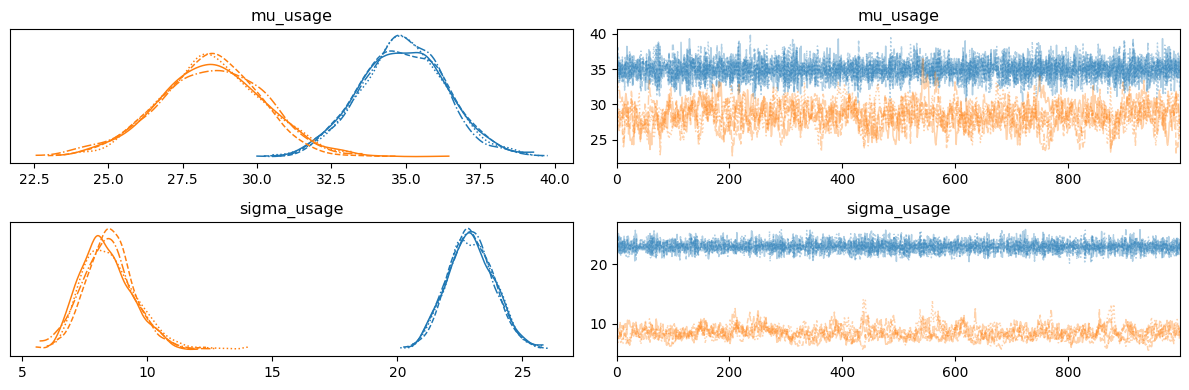

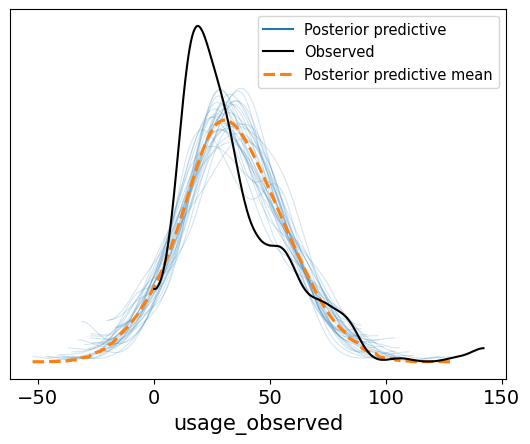

In [20]:
display(az.summary(idata, var_names=['mu_usage', 'sigma_usage']))

az.plot_trace(idata, var_names=['mu_usage', 'sigma_usage'])
plt.tight_layout()

az.plot_ppc(idata, num_pp_samples=30)

In [27]:
with pm.Model(coords=coords) as temp_model:
    
    temp_set = pm.Data('temp_set', 60)

    sigma_usage = pm.Exponential('sigma_usage', lam=1)

    usage_min = pm.Uniform('usage_min', lower=0, upper=30)
    k_heat = pm.Uniform('k_heat', lower=0, upper=5)  # 2 x 
    k_cool = pm.Uniform('k_cool', lower=0, upper=5)

    # Broadcast temp_set and temp_obs across k_heat and k_cool
    mu_usage = pm.math.switch(
        temp_obs < temp_set,
        k_heat * (temp_set - temp_obs) + usage_min,
        k_cool * (temp_obs - temp_set) + usage_min
    )

    usage = pm.Normal('usage', mu=mu_usage, sigma=sigma_usage, observed=usage_obs.T[0])

    temp_idata = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_usage, usage_min, k_heat, k_cool, usage_unobserved]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 26 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
k_heat,2.248,0.099,2.055,2.429,0.002,0.001,2814.0,2893.0,1.0
k_cool,0.611,0.208,0.221,1.005,0.004,0.003,2974.0,2157.0,1.0
usage_min,14.274,1.405,11.552,16.813,0.027,0.019,2764.0,2966.0,1.0


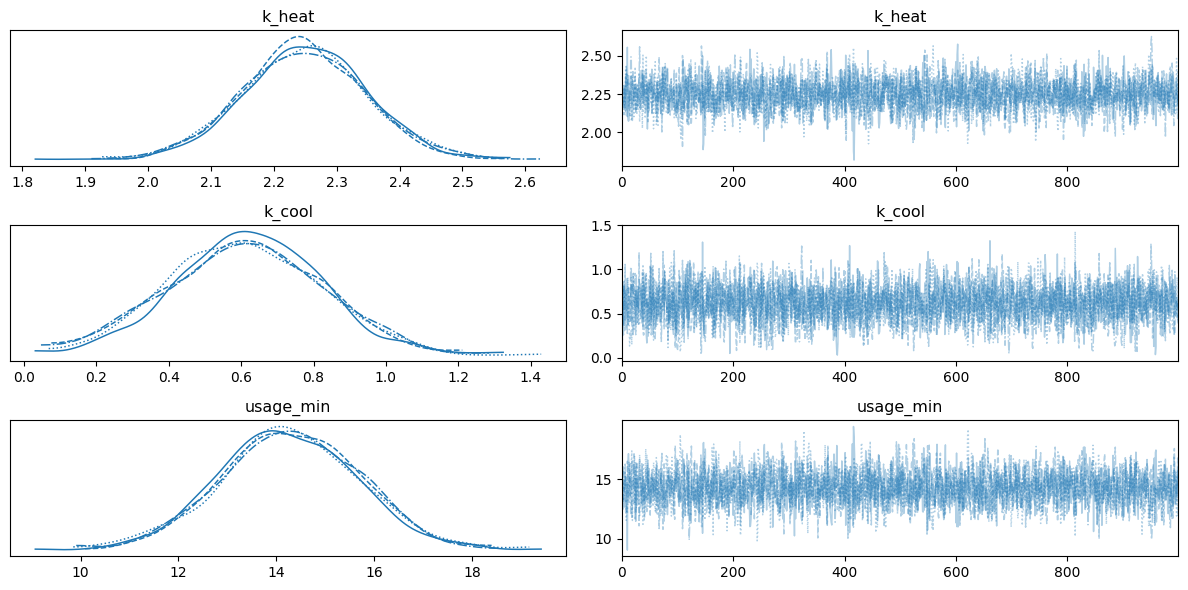

In [30]:
display(az.summary(temp_idata, var_names=['k_heat', 'k_cool', 'usage_min']))

az.plot_trace(temp_idata, var_names=['k_heat', 'k_cool', 'usage_min'])
plt.tight_layout()

In [31]:
temp_idata.posterior

<xarray.Dataset> Size: 10MB
Dimensions:                 (chain: 4, draw: 1000, usage_unobserved_dim_0: 21,
                             usage_dim_0: 288)
Coordinates:
  * chain                   (chain) int32 16B 0 1 2 3
  * draw                    (draw) int32 4kB 0 1 2 3 4 5 ... 995 996 997 998 999
  * usage_unobserved_dim_0  (usage_unobserved_dim_0) int32 84B 0 1 2 ... 19 20
  * usage_dim_0             (usage_dim_0) int32 1kB 0 1 2 3 ... 284 285 286 287
Data variables:
    usage_unobserved        (chain, draw, usage_unobserved_dim_0) float64 672kB ...
    sigma_usage             (chain, draw) float64 32kB 14.09 13.13 ... 14.04
    usage_min               (chain, draw) float64 32kB 14.28 12.87 ... 16.19
    k_heat                  (chain, draw) float64 32kB 2.206 2.33 ... 2.09 2.127
    k_cool                  (chain, draw) float64 32kB 0.4542 0.3768 ... 0.3954
    usage                   (chain, draw, usage_dim_0) float64 9MB 34.44 ... ...
Attributes:
    created_at:                 2024-12-02T15:13:18.936509+00:00
    arviz_version:              0.20.0
    inference_library:          pymc
    inference_library_version:  5.18.1
    sampling_time:              26.29286503791809
    tuning_steps:               1000

In [32]:
x_temp = np.linspace(10, 100, 100)
temp_set = 60

k_heat = temp_idata.posterior.k_heat.mean(dim=['chain', 'draw']).values
k_heat_ci = temp_idata.posterior.k_heat.quantile([0.025, 0.975], dim=['chain', 'draw']).to_numpy()

k_cool = temp_idata.posterior.k_cool.mean(dim=['chain', 'draw']).to_numpy()
k_cool_ci = temp_idata.posterior.k_cool.quantile([0.025, 0.975], dim=['chain', 'draw']).to_numpy()

usage_min = temp_idata.posterior.usage_min.mean(dim=['chain', 'draw']).values
usage_min_ci = temp_idata.posterior.usage_min.quantile([0.025, 0.975], dim=['chain', 'draw']).to_numpy()

<Axes: xlabel='temp_f', ylabel='USAGE (kWh)'>

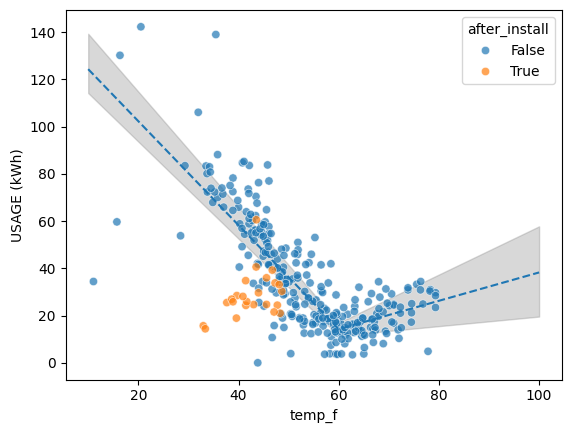

In [43]:
x_temp = np.linspace(10, 100, 100)
temp_set = 60

usage = [k_heat * (temp_set - temp) + usage_min if temp < temp_set else k_cool * (temp - temp_set)  + usage_min for temp in x_temp]
usage_low = [k_heat_ci[0] * (temp_set - temp) + usage_min_ci[0] if temp < temp_set else k_cool_ci[0] * (temp - temp_set)  + usage_min_ci[0] for temp in x_temp]
usage_high = [k_heat_ci[1] * (temp_set - temp) + usage_min_ci[1] if temp < temp_set else k_cool_ci[1] * (temp - temp_set)  + usage_min_ci[1] for temp in x_temp]

plt.plot(x_temp, usage, linestyle='--')
plt.fill_between(x_temp,
                 usage_low, usage_high,
                 alpha=0.3, color='grey')

sns.scatterplot(combined_df, x='temp_f', y='USAGE (kWh)', hue='after_install', alpha=0.7)

In [ ]:
(temp_obs < 20)

(288,)

In [49]:
usage_obs.T.shape

(2, 288)

In [ ]:
with pm.Model(coords=coords) as temp_model:
    
    temp_set = pm.Data('temp_set', 60)

    sigma_usage = pm.Exponential('sigma_usage', lam=1)

    usage_min = pm.Uniform('usage_min', lower=0, upper=30)
    k_heat = pm.Uniform('k_heat', lower=0, upper=5, shape=(2, 1))  # 2 x 
    k_cool = pm.Uniform('k_cool', lower=0, upper=5, shape=(2, 1))

    # Broadcast temp_set and temp_obs across k_heat and k_cool
    mu_usage = pm.math.switch(
        temp_obs < temp_set,
        k_heat * (temp_set - temp_obs) + usage_min,
        k_cool * (temp_obs - temp_set) + usage_min
    )

    usage = pm.Normal('usage', mu=mu_usage, sigma=sigma_usage, observed=usage_obs.T)

    full_idata = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_usage, usage_min, k_heat, k_cool, usage_unobserved]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 45 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"k_heat[0, 0]",2.231,0.100,2.042,2.418,0.003,0.002,969.0,1795.0,1.01
"k_heat[1, 0]",0.705,0.176,0.371,1.033,0.008,0.006,484.0,1262.0,1.01
"k_cool[0, 0]",0.584,0.205,0.212,0.987,0.007,0.005,966.0,1036.0,1.01
"k_cool[1, 0]",2.089,1.406,0.001,4.479,0.214,0.152,48.0,632.0,1.07
usage_min,14.599,1.397,12.103,17.373,0.045,0.032,971.0,2113.0,1.01


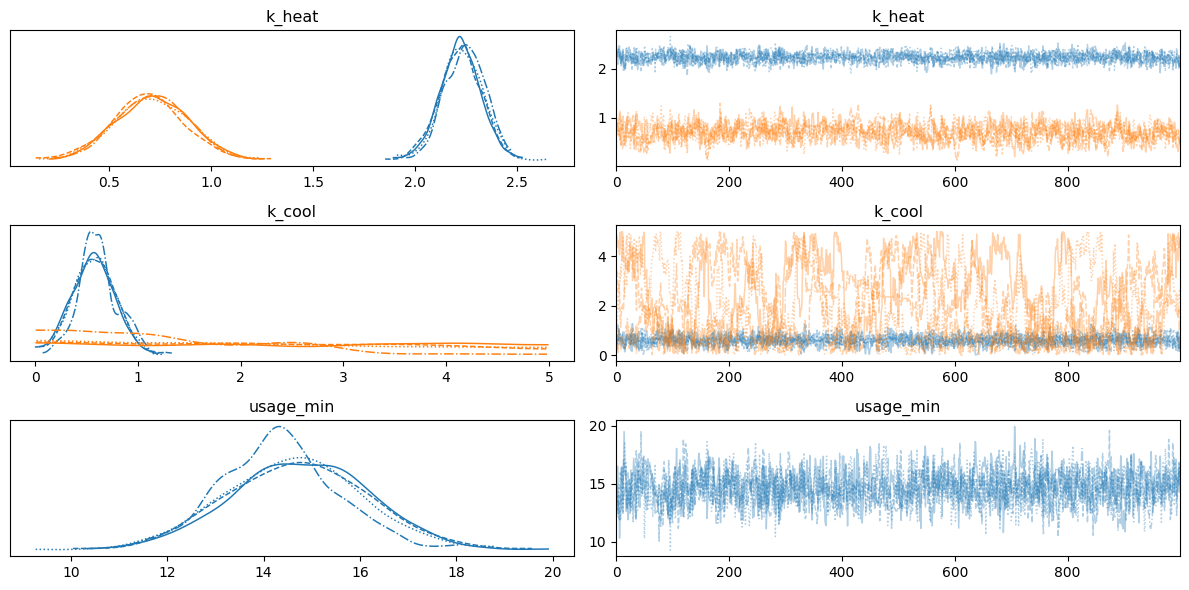

In [ ]:
display(az.summary(full_idata, var_names=['k_heat', 'k_cool', 'usage_min']))

az.plot_trace(full_idata, var_names=['k_heat', 'k_cool', 'usage_min'])
plt.tight_layout()

In [86]:
x_temp = np.linspace(10, 100, 100)
temp_set = 60

k_heat = idata.posterior.k_heat.mean(dim=['chain', 'draw']).values
k_heat_ci = idata.posterior.k_heat.quantile([0.025, 0.975], dim=['chain', 'draw']).values

k_cool = idata.posterior.k_cool.mean(dim=['chain', 'draw']).to_numpy()
k_cool_ci = idata.posterior.k_cool.quantile([0.025, 0.975], dim=['chain', 'draw']).values

usage_min = idata.posterior.usage_min.mean(dim=['chain', 'draw']).values
usage_min_ci = idata.posterior.usage_min.quantile([0.025, 0.975], dim=['chain', 'draw']).values

<Axes: xlabel='temp_f', ylabel='USAGE (kWh)'>

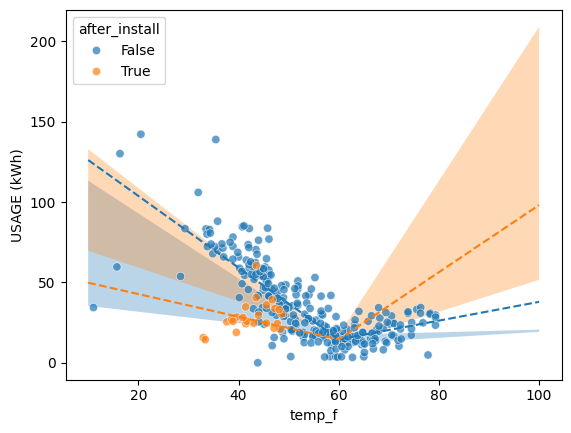

In [79]:
x_temp = np.linspace(10, 100, 100)
temp_set = 60

for idx in range(len(k_heat)):
    usage = [k_heat[idx][0] * (temp_set - temp) + usage_min if temp < temp_set else k_cool[idx][0] * (temp - temp_set)  + usage_min for temp in x_temp]
    usage_low = [k_heat_ci[idx][0][0] * (temp_set - temp) + usage_min_ci[0] if temp < temp_set else k_cool_ci[idx][0][0] * (temp - temp_set)  + usage_min_ci[0] for temp in x_temp]
    usage_high = [k_heat_ci[idx][1][0] * (temp_set - temp) + usage_min_ci[1] if temp < temp_set else k_cool_ci[idx][1][0] * (temp - temp_set)  + usage_min_ci[1] for temp in x_temp]

    plt.plot(x_temp, usage, linestyle='--')
    plt.fill_between(x_temp,
                    usage_low, usage_high,
                    alpha=0.3)

sns.scatterplot(combined_df, x='temp_f', y='USAGE (kWh)', hue='after_install', alpha=0.7)